PROJECT : Order Cancellation Analysis (Year 2022)

ANALYST : Samresh

STARTED DATE : 19-01-2026

LAST UPDATE : 24-01-2026

BUSINESS PROBLEM : CEO needs to understand the scope of order cancellation problem urgently. Also, how much revenue is being lost and reason?

OBJECTIVES :
Deliver initial findings by tomorrow EOD
1. How many order were cancelled?
2. How much revenue is being lost?
3. Where is the problem? (Breakdown by: Product/Region/Time)

DATA SOURCE :
1. File : Amazon Sales dataset
2. Time Period : Jan - Dec 2022
3. Data Provided by : Rahul (Perplexity)

KEY DEFINATION:
* Cancelled order : Status = 'Cancelled' (All types of Cancellation)
* Financial impact : Total revenue lost on order cancellation

DELIVERABLES :
* Email summary with inital findings with key numbers
* 2-3 clear charts
* Professional insights

Stakeholder : Rahul (Perplexity)

# Importing all required libraries

In [53]:
# IMPORTING IMPORTANT LIBRARIES FOR ANALYSIS
# ===========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from matplotlib.ticker import EngFormatter
sns.set_style("whitegrid")

## 1. Data loading and Intial Exploration
**Goal:** Load the dataset and understanding it's structure.

**Data Source:** Amazon Sales Dataset.csv provided by Rahul (Perplexity) CEO

**Time Period:** Jan - Dec 2022

In [54]:
# LOADING DATASET AND MAKING COPY OF RAW DATA
# =======================================================

raw = pd.read_csv('/content/drive/MyDrive/Dataset/Amazon Sale Report.csv', low_memory=False)
data = raw.copy()
pd.set_option('Display.max_columns', None)

In [55]:
data.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [56]:
# TOTAL ROWS AND COLUMNS IN DATASET (SHAPE)
row, cols = data.shape

print(f'Total Rows : {row} \nTotal columns {cols}')

Total Rows : 128975 
Total columns 24


In [57]:
# NOT NULL VALUE AND DATA TYPE
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [58]:
# EXPLORING COLUMNS AVAILABLE IN DATASET
data.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [59]:
# STANDARDIZING COLUMN NAME
# =============================

data.columns = data.columns.str.strip().str.lower().str.replace(r'[^0-9a-zA-Z]+', '_', regex=True)

###Key Findings : (Initial Observations)
* Dataset has Row : 128975 (total orders) and columns : 24 (total features)
* Columns include : ('index', 'order_id', 'date', 'status', 'fulfilment',
       'sales_channel', 'ship_service_level', 'style', 'sku', 'category',
       'size', 'asin', 'courier_status', 'qty', 'currency', 'amount',
       'ship_city', 'ship_state', 'ship_postal_code', 'ship_country',
       'promotion_ids', 'b2b', 'fulfilled_by', 'unnamed_22')
* Some columns has null values, some has wrong datatype

**Initial Target Columns :**
(order_id, date, status, category, courier_status, currency, amount and ship_state) for this analysis

##2. Data Quality Assessment
**Goal :** Evaluate reliability and completeness of data to ensure analysis accuracy and identify data quality issue which may impact business decision.

**Approach :**
* Defining function to calculate missing values, it's count and percentage(%)
* Exploring duplicates and it's count in dataset
* Inconsistency in any Target columns (Formating issue and Incorrect DataType)
* Detecting outliers and anomalies in dataset

In [60]:
# DEFINING FUNCTION TO CHECK MISSING COUNT AND ITS PERCENTAGE IN EACH COLUMN
# ========================================================================

def missing_data(df):
    missing_count = df.isna().sum().sort_values(ascending=False)
    missing_count = missing_count[missing_count != 0]
    missing_perc = (missing_count * 100 / len(df)).round(2)

    return pd.DataFrame({'missing_count': missing_count, 'missing %': missing_perc})

In [61]:
# APPLYING FUNCTION TO EXPLORE MISSING VALUES IN DATASET

print(f'Missing values : \n{missing_data(data)}')

Missing values : 
                  missing_count  missing %
fulfilled_by              89698      69.55
promotion_ids             49153      38.11
unnamed_22                49050      38.03
currency                   7795       6.04
amount                     7795       6.04
courier_status             6872       5.33
ship_country                 33       0.03
ship_city                    33       0.03
ship_state                   33       0.03
ship_postal_code             33       0.03


In [62]:
# CHECKING DUPLICATE VALUES IN DATASET

dup_count = data.duplicated().sum()

print(f'Duplicate count : {dup_count}')

Duplicate count : 0


In [63]:
# DATATYPE OF INITIAL TARGET COLUMN

target_variables = data[['order_id', 'date', 'status', 'category', 'courier_status', 'currency', 'amount', 'ship_state']]
print(f'Datatypes of Intial Target Variable : \n{target_variables.dtypes}')

Datatypes of Intial Target Variable : 
order_id           object
date               object
status             object
category           object
courier_status     object
currency           object
amount            float64
ship_state         object
dtype: object


In [64]:
# UNIQUE VALUES IN TARGET COLUMN
print(f'Count Unique Values : \n{target_variables.nunique()}')

Count Unique Values : 
order_id          120378
date                  91
status                13
category               9
courier_status         3
currency               1
amount              1410
ship_state            69
dtype: int64


In [65]:
# STATISTICAL DESCRIPTION OF NUMERICAL COLUMN
data.describe()

,index,qty,amount,ship_postal_code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


### Key Findings : (Data Quality Assessment)
**High Missing Rate (>50%) :**
* fulfilled_by 69.55% (Not required for analysis)

**Medium Missing Rate (10%-50%) :**
* promotion_ids 38.11% (Not required for analysis)
* unnamed_22 38.03% (Not required for analysis)

**Low Missing Rate (<10%) :**
* currency 6.04%
* amount 6.04%
* courier_status 5.33%
* ship_country 0.03%
* ship_city 0.03%
* ship_state 0.03%
* ship_postal_code 0.03%

**No Duplicates :** Considering duplicates which is identical (all columns are same)

**Data Types :** Date column is in object, need to convert to datetime. ship_postal_code in float, need to convert in string or int.

**Unique Value :** ship_state is expected to be (~28-36) as india has 28 states and 8 Union Territories (Seems format issue, would explore further)

**For This Analysis : **
* Target Columns (order_id, date, status, category, courier_status, amount and ship_state)
* Missing values (status, category, courier_status, currency, amount and ship_state) are manageble and other columns are not critical for currect scope
* We will create flags for missing values for this urgent and descriptive analysis.

In [66]:
# EXPLORING UNIQUE STATE NAME TO FIND INCOCENTENCY IN STATE NAME
print(f'Unique states : \n{data['ship_state'].unique()}')

Unique states : 
['MAHARASHTRA' 'KARNATAKA' 'PUDUCHERRY' 'TAMIL NADU' 'UTTAR PRADESH'
 'CHANDIGARH' 'TELANGANA' 'ANDHRA PRADESH' 'RAJASTHAN' 'DELHI' 'HARYANA'
 'ASSAM' 'JHARKHAND' 'CHHATTISGARH' 'ODISHA' 'KERALA' 'MADHYA PRADESH'
 'WEST BENGAL' 'NAGALAND' 'Gujarat' 'UTTARAKHAND' 'BIHAR'
 'JAMMU & KASHMIR' 'PUNJAB' 'HIMACHAL PRADESH' 'ARUNACHAL PRADESH'
 'MANIPUR' 'Goa' 'MEGHALAYA' 'GOA' 'TRIPURA' 'LADAKH' 'DADRA AND NAGAR'
 'SIKKIM' 'Delhi' nan 'ANDAMAN & NICOBAR ' 'Punjab' 'Rajshthan' 'Manipur'
 'rajasthan' 'Odisha' 'NL' 'Bihar' 'MIZORAM' 'punjab' 'New Delhi'
 'Rajasthan' 'Punjab/Mohali/Zirakpur' 'Puducherry' 'delhi' 'RJ'
 'Chandigarh' 'orissa' 'LAKSHADWEEP' 'goa' 'PB' 'APO' 'Arunachal Pradesh'
 'AR' 'Pondicherry' 'Sikkim' 'Arunachal pradesh' 'Nagaland' 'bihar'
 'Mizoram' 'rajsthan' 'Orissa' 'Rajsthan' 'Meghalaya']


**Observation :** Ship State name has inconsistencies such as -
"ap", "apo", "AR", "Punjab/Mohali/Zirakpur", "Rajshthan", Lowercase and Uppercase and so on. Action required (rename abbreviation to standarded state name, formating to common case, e.g. lower/upper/title)

##3. Data Cleaning : (Focused on Target columns)
* Flag "Unknow" to missing values (preserves actual shape of data)
* Standardizing ship_state (Avoid incorrect Groupping)
* Converting date column to datetime and deriving month column

In [67]:
# Defining function to standardize state name
# ==============================================

def state_clean(state):
    if pd.isna(state):
        return 'Unknown'

    state = str(state).lower().strip()
    state = state.replace('&', 'and')

    state_mapping = {
        #ARUNACHAL PRADESH Variation
        'ar' : 'arunachal pradesh',

        #ANDHRA PRADESH
        'apo' : 'andhra pradesh',

        #NEW DELHI
        'new delhi' : 'delhi',

        #ORISSA
        'odisha' : 'orissa',

        #PUNJAB
        'pb' : 'punjab',
        'punjab/mohali/zirakpur' : 'punjab',

        #PONDICHERRY
        'puducherry' : 'pondicherry',

        #RAJASTHAN
        'rj' : 'rajasthan',
        'rajsthan' : 'rajasthan',
        'rajshthan' : 'rajasthan',

        #NAGALAND
        'nl' : 'nagaland'}
    cleaned = state_mapping.get(state, state)
    return cleaned.title()

In [68]:
# APPLYING FUNCTION TO STANDARDING STATES NAME
data['ship_state_clean'] = data['ship_state'].apply(state_clean)
data['ship_state_clean'].nunique()

37

In [69]:
# CONVERTING TO DATE COLUMN AND CREATING MONTH AND DAY FEATURE
# ============================================================

# CONVERTING DATE COLUMN TO DATETIME
data['date'] = pd.to_datetime(data['date'], dayfirst=True, format='mixed')

# DERIVING MONTHS FROM DATE COLUMN
data['months'] = data['date'].dt.month_name()

# ORDER OF MONTH
month_order = ['January', 'February', 'March', 'April', 'May', 'June','July', 'August', 'September', 'October', 'November', 'December']

# CONVERTING MONTH COLUMN TO CATEGORICAL COLUMN
data['months'] = pd.Categorical(data['months'], categories=month_order, ordered=True)

## 4. Analyzing Business Impact
**Goal :** Identify Cancellations

**Approach :**
* Checking "courier_status" and "status" columns to identify type of cancellations
* Cancellation might be in defferent stages like courier level and system status level

In [70]:
# Exploring order breakdown and count by system status and courier status to identify cancelled orders
orders_breakdown = data.groupby(['status', 'courier_status'], dropna=False)['order_id'].count()
print(f'Orders breakdow by system status and courier status : \n{orders_breakdown}')

Orders breakdow by system status and courier status : 
status                         courier_status
Cancelled                      Cancelled          5840
                               Unshipped          5631
                               NaN                6861
Pending                        Cancelled             2
                               Shipped              10
                               Unshipped           646
Pending - Waiting for Pick Up  Unshipped           281
Shipped                        Cancelled            93
                               Shipped           77596
                               Unshipped           115
Shipped - Damaged              Shipped               1
Shipped - Delivered to Buyer   Shipped           28761
                               NaN                   8
Shipped - Lost in Transit      Shipped               5
Shipped - Out for Delivery     Shipped              35
Shipped - Picked Up            Shipped             973
Shipped - Rejected 

###Key Findings : (Business Impact)
Courier status shows 5840 (cancelled) and 5631 (unshipped) which are cancelled orders in system status, 2 (cancelled) pending in system status, 93 (cancelled) which shows shipped in system status are cancelled, all missing courier_status are either "Cancelled" or "Returned" excluding 8 orders which has been delivered to buyer. The orders which has been shipped, they are either rejected by buyer(11), returned (1950 + 3) or returning (145) which can be considered as cancelled. Orders which are pending to deliver, are neither shipped nor cancelled so not considering Pending orders as cencelled.

Considering Cancelled orders where courier_status are cancelled and missing excluding 8 missing which is delivered, where system status are "Cancelled", "Shipped - Rejected by Buyer", "Shipped - Returned to Seller" and "Shipped - Returning to Seller"


##5. Data Preparation : Creating Cancellation Flag

**Goal :** Cancellation is scattered across multiple columns (couries_status and status) and conditions (cancelled, returned and rejected), need single clear indication for analysis.

**Approach :**
* Include orders from courier_status and status ("Missing", "Cancelled", "Shipped - Returned to Seller" and "Shipped - Returning to Seller") as cancelled
* Include cancelled order with amount as revenue impact(Orders where amount is not null or amount is greater than 0)
* Include cancelled order without amount as non revenue impact (Orders where amount is null or 0)

In [71]:
# CREATING FLAGS FOR CANCELLED ORDERS AND REVENUE IMPACTED ORDERS
# =====================================================================

# Creating flag for all cancelled order
data['has_cancelled'] = (data['status'].str.contains('Cancelled|Returned|Returning|Rejected', case=False, na=False) |
                        ((data['courier_status'].isna()) & ~(data['status']=='Shipped - Delivered to Buyer')))

# Creating flag for revenue impacet
data['has_revenue_impacted'] = ((data['has_cancelled'] == True) & ((data['amount'].notna()) | (data['amount'] > 0)))

# creating flag for cancelled order which did not impacted revenue
data['no_revenue_impacted'] = (data['has_cancelled']==True) & (data['has_revenue_impacted']==False)

###6. Measuring Business Impact
**Goal :** Calculating Total Cancellations and Revenue Loss to measure how bad the problem is.

**Approach :**
* Aggregating Total cancelled orders
* Calculating Cancellation Rate(%)
* Aggregating Revenue lost amount
* Calculating Revenue lost Rate(%)

In [72]:
# CALCULATING CANCELLATION COUNT AND REVENUE LOST AMOUNT
# ===========================================================================

# Total Orders
total_orders = data['order_id'].count()
print(f'Total orders : {total_orders}')

# Cancelled orders
total_cancelled_orders = data['has_cancelled'].sum()
print(f'\nTotal Cancelled orders : {total_cancelled_orders}')

# Cancelled orders with revenue impact
cancelled_orders_with_revenue_impact = data['has_revenue_impacted'].sum()
print(f'\nTotal cancelled orders with revenue : {cancelled_orders_with_revenue_impact}')

# Cancelled orders without revenue impact
cancelled_orders_without_revenue_impact = data['no_revenue_impacted'].sum()
print(f'\nTotal cancelled order without revenue impact : {cancelled_orders_without_revenue_impact}')

# Revenue Expected
revenue_expected = data['amount'].sum().round(2)
print(f'\nTotal Revenue Expected : ₹ {revenue_expected}')

# Revenue Lost
revenue_lost = data.query('has_revenue_impacted==True')['amount'].sum().round(2)
print(f'\nTotal Revenue Lost : ₹ {revenue_lost}')

Total orders : 128975

Total Cancelled orders : 20441

Total cancelled orders with revenue : 12872

Total cancelled order without revenue impact : 7569

Total Revenue Expected : ₹ 78592678.3

Total Revenue Lost : ₹ 8303843.3


## Key Findings : (Business Impact)
1. Cancelled Orders with amount : Cancelled either by system, during courier and returned after shipping (Revenue Impact)
2. Cancelled Orders without amount : Cancelled either by system or during courier where amount missing or 0 (No Revenue Impact)
* Total orders : 128975
* Total Cancelled orders : 20441
* Total cancelled orders with revenue : 12872
* Total cancelled order without revenue impact : 7569
* Total Revenue Expected : ₹ 78592678.3
* Total Revenue Lost : ₹ 8296548.3

###6. Metrics Calculation : Measure Impact Rate(%)
**Cancellation Rate :**
* Overall Cancellation Rate
* Cancellation Rate : Revenue Impact vs Non Revenue Impact (cancelled order with amount vs cancelled order without amount)

**Revenue Lost Rate :**
* Lost Revenue percentage (Total cancelled order where payment was done or expected to be done)


In [73]:
# METRICS CALCULATION : CANCELLATION RATE AND REVENUE LOST RATE
# =================================================================

# Calculating cancellation rate
cancellation_rate = (total_cancelled_orders * 100 / total_orders).round(2)
print(f'Cancellation Rate : {cancellation_rate}%')

# Calculating cancellation rate with revenue impact
cancellation_rate_with_revenue_impact = ((cancelled_orders_with_revenue_impact / total_orders) * 100).round(2)
print(f'\nCancellation rate with revenue impact : {cancellation_rate_with_revenue_impact}%')

# Calculating cancellation rate without revenue impact
cancellation_rate_without_revenue_impact = ((cancelled_orders_without_revenue_impact / total_orders) * 100).round(2)
print(f'\nCancellation rate without revenue impact : {cancellation_rate_without_revenue_impact}%')

# Calculating revenue lost rate
revenue_lost_rate = ((revenue_lost / revenue_expected) * 100).round(2)
print(f'\nRevenue Lost Rate : {revenue_lost_rate}%')

# AVERAGE REVENUE LOSS PER CENCELLED ORDER
avg_revenue_loss_per_cancellation = revenue_lost / total_cancelled_orders
print(f'\nAverage Revenue Loss Per Cancelled Order : {avg_revenue_loss_per_cancellation.round(2)}')

Cancellation Rate : 15.85%

Cancellation rate with revenue impact : 9.98%

Cancellation rate without revenue impact : 5.87%

Revenue Lost Rate : 10.57%

Average Revenue Loss Per Cancelled Order : 406.23


## Key Findings : (Metrics Calculation)
**Cancellation :** Operational Impact
* Total cancelled orders : 20441  (Including Cancelled and Returned orders)
* Cancellation rate : 15.85%   (Operational Metric)
---
* Total cancelled orders impacted revenue : 12872    (Including only orders which has amount)
* Cancellation rate for impacted revenue : 9.98%
---
* Total cancelled orders non impacted revenue : 7569    (Including only orders which did not have amount)
* Cancellation rate for non impacted revenue : 5.87%

**Revenue :** Financial Impact
* Revenue to be expected : ₹ 78592678.3
* Revenue lost :  ₹ 8296548.3
* Revenue lost Percentage : 10.57%  (Financial Metric)
* Average Revenue loss per cancelled order : 406.23

###7. KPI Visualization
* Overall Cancellation Rate(%)
* Cacellation Rate Breakdown (Revenue Impacted vs No Revenue Impacted)
* Revenue Lost Rate

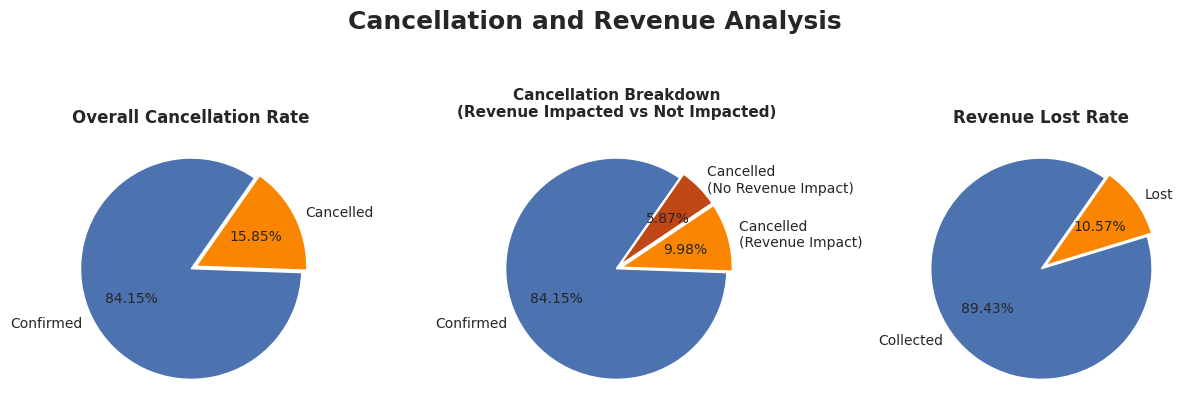

In [74]:
# PREPARING DATA FOR CHARTS
# ====================================

successful_orders = total_orders - total_cancelled_orders
collected_revenue = revenue_expected - revenue_lost

# Cancellation Metric
cancellation_rate = [successful_orders, total_cancelled_orders]
cancellation_labels = ['Confirmed', 'Cancelled']
cancellation_colors = ['#4C72B0', '#fa8500']

# Cancellation Metric Breakdown
cancellation_rate_breakdown = [successful_orders, cancelled_orders_with_revenue_impact, cancelled_orders_without_revenue_impact]
breakdown_labels = ['Confirmed', 'Cancelled \n(Revenue Impact)', 'Cancelled \n(No Revenue Impact)']
breakdown_colors = ['#4C72B0', '#fa8500', '#bf4615']

# Revenue Lost Metric
revenue_lost_rate = [collected_revenue, revenue_lost]
revenue_labels = ['Collected', 'Lost']
revenue_colors = ['#4C72B0', '#fa8500']

#Defining Canvas/Figure
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
fig.suptitle('Cancellation and Revenue Analysis', fontsize=18, fontweight='bold')

# PLOTTING ALL METRICS
# ================================
ax1.pie(cancellation_rate, autopct='%.2f%%', labels=cancellation_labels, colors=cancellation_colors, explode=[0, 0.05], startangle=55)
ax1.set_title('Overall Cancellation Rate', fontweight='bold')

#Plotting Break down Order cancallations
ax2.pie(cancellation_rate_breakdown, autopct='%.2f%%', labels=breakdown_labels, colors=breakdown_colors, explode=[0, 0.05, 0.05], startangle=55)
ax2.set_title('Cancellation Breakdown\n(Revenue Impacted vs Not Impacted)', fontsize=11, pad=10, fontweight='bold')

ax3.pie(revenue_lost_rate, labels=revenue_labels, colors=revenue_colors, autopct='%.2f%%', explode=[0, 0.05], startangle=55)
ax3.set_title('Revenue Lost Rate', fontweight='bold')

plt.tight_layout()

fig.savefig(
    'Chart1_cancellation_&_revenue_analysis_overview.png',
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

###Geographical Analysis
**Goal :** Analyse state wise cancellation to determine whether cancellation is constent in entire states or there are states, contibuting most to revenue loss

**Approach :**
* Calculate Cancellation and Revenue loss by each states
* Analyze Volume vs Rate trade-off

In [75]:
# CANCELLATION BREAKDOWN BY STATES
# ==================================================

# Calculating orders and cancelled orders by state
cancellation_by_state = data.groupby('ship_state_clean').agg(orders=('order_id', 'count'),
                                                             cancelled=('has_cancelled', 'sum'),
                                                             impacted = ('has_revenue_impacted', 'sum')).reset_index()

# Calculating cancellation rate by state
cancellation_by_state['cancellation(%)'] = ((cancellation_by_state['cancelled'] / cancellation_by_state['orders']) * 100).round(2)

cancellation_by_state['impacted(%)'] = ((cancellation_by_state['impacted'] / cancellation_by_state['orders']) * 100).round(2)


In [76]:
cancellation_by_state.sort_values('cancellation(%)', ascending=False)

,ship_state_clean,orders,cancelled,impacted,cancellation(%),impacted(%)
33,Unknown,33,10,8,30.30,24.24
18,Lakshadweep,4,1,1,25.00,25.00
23,Mizoram,76,18,15,23.68,19.74
0,Andaman And Nicobar,257,56,42,21.79,16.34
12,Himachal Pradesh,788,162,98,20.56,12.44
13,Jammu And Kashmir,702,139,86,19.80,12.25
4,Bihar,2114,405,255,19.16,12.06
16,Kerala,6585,1258,827,19.10,12.56
14,Jharkhand,1456,278,176,19.09,12.09
3,Assam,1663,316,203,19.00,12.21


In [77]:
# REVENUE LOSS BREAKDOWN BY STATES
# ==================================================

# CREATING COLUMN FOR REVENUE LOSS
data['revenue_loss'] = np.where(data['has_revenue_impacted']==True, data['amount'], 0)

# REVENUE BREAKDOWN BY STATES
revenue_by_states = data.groupby('ship_state_clean').agg(revenue_expected=('amount', 'sum'),
                                     revenue_lost=('revenue_loss', 'sum')).reset_index()

# REVENUE LOSS RATE(%)
revenue_by_states['revenue_loss(%)'] = ((revenue_by_states['revenue_lost'] / revenue_by_states['revenue_expected']) * 100).round(2)

display(revenue_by_states.sort_values('revenue_lost', ascending=True))

,ship_state_clean,revenue_expected,revenue_lost,revenue_loss(%)
18,Lakshadweep,3175.29,734.29,23.13
33,Unknown,18671.00,3659.00,19.60
7,Dadra And Nagar,42138.92,5376.92,12.76
17,Ladakh,38388.43,5603.43,14.60
23,Mizoram,41948.71,8140.71,19.41
32,Tripura,92548.40,10934.40,11.81
2,Arunachal Pradesh,98265.00,12721.00,12.95
21,Manipur,213981.99,14004.99,6.54
29,Sikkim,140828.66,16820.66,11.94
22,Meghalaya,119871.81,17972.81,14.99


###Key Findings : (Geographical Analysis)
Analysis shows, there are state which has high cancellation rate(%) and high revenue loss rate(%) but volume (order count) is very less, impact lower revenue loss and there are states which has lower cancellation rate(%) and lower revenue loss rate(%) but volume (order count) is high, impact higher revenue loss.

Statistical mersurement is not reliable for lower volume. (e.g. Lakshdweep has 4 orders out of which 1 cancelled with cancellation_rate 25%, improving 25% to 0%, we would save 1 order whereas in Maharashtra, we have 22260 orders out of which 3236 cancelled with cancellation rate 14.54%, improving 14.54% to 10% only we (4.54% * 22260) would save 1000+ orders), similarly Lakshdweep has ₹734.29 revenue loss out of ₹3175.29 expected revenue with 23.13%, improving 23.13% to 0%, we would save ₹734.29 whereas Maharashtra ₹1280597.14 revenue loss out of ₹13335534.14 expected revenue with 9.60% revenue loss rate, improving 9.60% to 5% only we (4.60% * ₹13335534.14) would save 800+ times of Lakshdweeps revenue loss.

Conclusion : Looking at cancellation rate(%) alone suggests to prioritize "Unknown"- (30.30%), "Lakshdweep"-(25%), however this would be strategically incorrect from business impact prospective. Hence, focusing on **High Volume states**, not on **High Rate states**. Which recommends Parato analysis.

### Pareto Analysis (80/20 Rule)
**Goal :**
* Identify 20% states which contibutes 80% of the Order Cancellation and Revenue Loss
* Identify Target states to improve for lowering down revenue impact

**Approach:**
* Calculate each state's contribution to total order cancellation and revenue loss
* Calculate cumulative contribution percentage
* Identify states where cumulative reaches ~80%

**Expected Outcome :** List of prioritized Top 10 states which is contributing ~80% cancellation to improve revenue losss

In [78]:
# CALCULATING CONTIBUTION(%) TO CANCELLATOIN AND CUMULATIVE CANCELLATON(%)
# ==========================================================================
total_cancelled = cancellation_by_state['cancelled'].sum()

# CALCULATING EACH STATE'S CONTRIBUTION(%) TO WHOLE CANCELLATION
cancellation_by_state['contribution(%)'] = ((cancellation_by_state['cancelled'] / total_cancelled) * 100).round(2)
cancellation_by_state = cancellation_by_state.sort_values('contribution(%)', ascending=False)

# CALCULATING CUMULATIVE CONTRIBUTION(%) IN CANCELLATION
cancellation_by_state['cumulative(%)'] = cancellation_by_state['contribution(%)'].cumsum()


display(cancellation_by_state)

,ship_state_clean,orders,cancelled,impacted,cancellation(%),impacted(%),contribution(%),cumulative(%)
20,Maharashtra,22260,3236,2072,14.54,9.31,15.83,15.83
15,Karnataka,17326,2452,1524,14.15,8.80,12.00,27.83
34,Uttar Pradesh,10638,1847,1161,17.36,10.91,9.04,36.87
31,Telangana,11330,1800,1114,15.89,9.83,8.81,45.68
30,Tamil Nadu,11483,1752,1089,15.26,9.48,8.57,54.25
16,Kerala,6585,1258,827,19.10,12.56,6.15,60.40
8,Delhi,7048,1028,628,14.59,8.91,5.03,65.43
36,West Bengal,5963,1008,597,16.90,10.01,4.93,70.36
1,Andhra Pradesh,5431,991,623,18.25,11.47,4.85,75.21
10,Gujarat,4489,644,433,14.35,9.65,3.15,78.36


In [79]:
# CALCULATING CONTIBUTION(%) TO CANCELLATOIN AND CUMULATIVE CANCELLATON(%)
# ==========================================================================
total_revenue_lost = revenue_by_states['revenue_lost'].sum()

# CALCULATING EACH STATE'S CONTRIBUTION(%) TO WHOLE REVENUE LOSS
revenue_by_states['loss_contribution(%)'] = ((revenue_by_states['revenue_lost'] / revenue_lost) * 100)
revenue_by_states = revenue_by_states.sort_values('loss_contribution(%)', ascending=False)

# CALCULATING CUMULATIVE CONTRIBUTION(%) IN REVENUE LOSS
revenue_by_states['cumulative_loss(%)'] = revenue_by_states['loss_contribution(%)'].cumsum()

display(revenue_by_states)

,ship_state_clean,revenue_expected,revenue_lost,revenue_loss(%),loss_contribution(%),cumulative_loss(%)
20,Maharashtra,13335534.14,1280597.14,9.60,15.421740,15.421740
15,Karnataka,10481114.37,957303.37,9.13,11.528437,26.950178
34,Uttar Pradesh,6816642.08,792999.08,11.63,9.549784,36.499961
31,Telangana,6916615.65,732103.65,10.58,8.816443,45.316405
30,Tamil Nadu,6515650.11,653868.11,10.04,7.874283,53.190688
16,Kerala,3830227.58,502996.58,13.13,6.057395,59.248083
8,Delhi,4393522.41,411957.41,9.38,4.961045,64.209128
1,Andhra Pradesh,3219831.72,395979.72,12.30,4.768632,68.977759
36,West Bengal,3507880.44,382710.44,10.91,4.608835,73.586595
11,Haryana,2882092.99,279157.99,9.69,3.361793,76.948387


### Key Findings : (Pareto Analysis)
* Cancellation Rate(%) and Revenue Loss Rate(%) are high for low volume (Low Orders) states "Lakshdweep", "Unknown" and "Dadar and Nagar"...so on but contribution(%) to whole cancallation is 0.0088%, 0.044% and 0.064%, however Cancellation Rate(%) and Revenue Loss Rate(%) are low for high volume (High Orders) states "Maharashtra", "Karnataka" and "Uttar Pradesh"...so on but contribution(%) to whole cancellation is 15.42%, 11.52% and 9.54%.

* Pareto Analysis shows cancellation and revenue loss is not unifomaly distributed, it is concentrated on high volumne states, which is contributing to actual business impact, improving states with highly cancelled orders would improve revenue loss.

* Top 10 states contributes 76.95% revenue loss and rest 27 states including "Unknown" flag contributes 23.05% revenue loss, improving 30% for Top 10 states would save (30% * ~6389673.49 = ~1916902) which is 23% recovery of total revenue lost

### Visualizing Top 10 State
* CHART 1: Top 10 States : ~78.35% contributer of total cancelled orders
* CHART 2: Top 10 States : ~76.95% contributer of total revenue loss

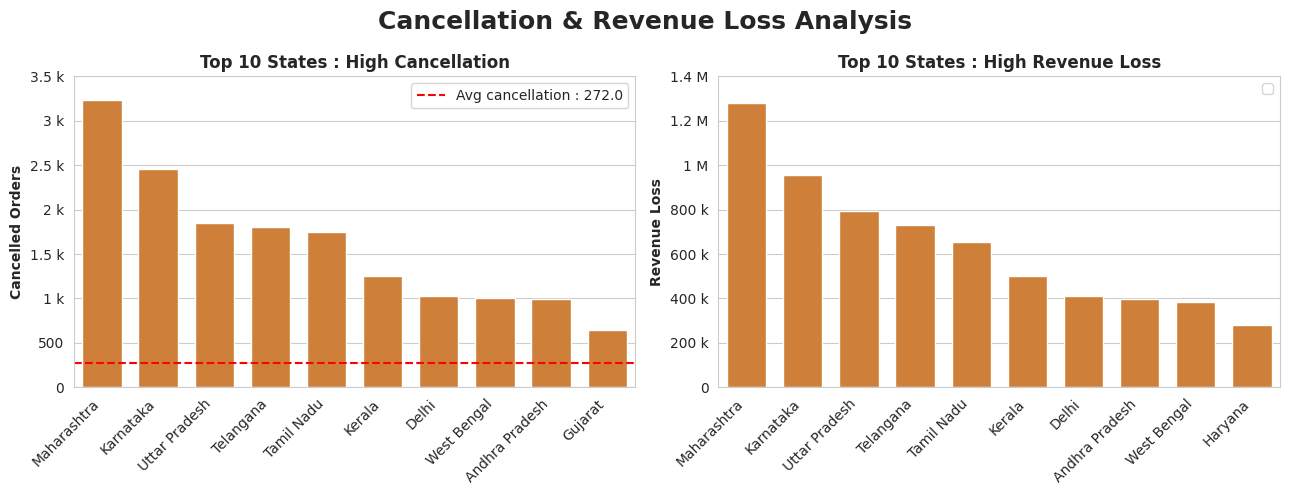

In [80]:
# PREPARING DATA TO PLOT
# ===========================================================================

top_states_by_cancellation = cancellation_by_state.head(10)
top_states_by_revenue_loss = revenue_by_states.head(10)


avg_cancelled_count = cancellation_by_state['cancelled'].sort_values().median()

# CHART : PLOTTING TOP 10 STATES BY HIGHEST CANCELLATION AND REVENUE LOSS
# =============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Cancellation & Revenue Loss Analysis', fontsize=18, fontweight='bold')

# CHART 1: TOP 10 STATES IN HIGH CANCELLATION
sns.barplot(data=top_states_by_cancellation, x='ship_state_clean', y='cancelled', width=0.7, color='#e67e22', ax=ax1)

ax1.set_title('Top 10 States : High Cancellation', fontsize=12, fontweight='bold')
ax1.set_xlabel(None)
ax1.set_ylabel('Cancelled Orders', fontweight='bold')
ax1.set_ylim(0, 3500)
ax1.yaxis.set_major_formatter(EngFormatter())
ax1.axhline(avg_cancelled_count, color='red', linestyle="--", label=f'Avg cancellation : {avg_cancelled_count}')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.legend()
#ax1.spines[['right', 'top']].set_visible(False)

# CHART 2: TOP 10 STATES IN HIGH REVENUE LOSS
sns.barplot(data=top_states_by_revenue_loss, x='ship_state_clean', y='revenue_lost',width=0.7, color='#e67e22', ax=ax2)

ax2.set_title('Top 10 States : High Revenue Loss', fontsize=12, fontweight='bold')
ax2.set_xlabel(None)
ax2.set_ylabel('Revenue Loss', fontweight='bold')
ax2.set_ylim(0, 1_400_000)
ax2.yaxis.set_major_formatter(EngFormatter())
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.legend()

plt.tight_layout()

fig.savefig(
    'Chart2_top_10_states_high_cancellation_revenue.png',
    dpi = 300,
    bbox_inches = 'tight'
)


plt.show()

###Monthly Trends
**Goal :**
* Identify spike and pattern to determine if the problem is seasonal or triggered by any event.
* Identify if cancellation is increasing, decreasing or stable.

**Approach :**
* Calculate Order and Cancellation count by each month
* Calculate cancellation rate(%) and revenue lost rate(%)
* Compare absolute number (order and cancellation count) vs cancellation(%) and revenue lost rate(%)
* Compare month-over-month (MoM) change

In [81]:
# METRICS : CANCELLATION TRENDS BY MONTH
# ===========================================================

# Calculating month wise orders and cancelled orders
cancellation_by_month = data.groupby('months').agg(total_orders = ('order_id', 'count'),
                                                    cancelled_orders = ('has_cancelled', 'sum'),
                                                    revenue_impact_orders = ('has_revenue_impacted', 'sum')).reset_index()
cancellation_by_month['cancellation_rate'] = ((cancellation_by_month['cancelled_orders'] / cancellation_by_month['total_orders']) * 100).round(2)
cancellation_by_month['impact_rate'] = ((cancellation_by_month['revenue_impact_orders'] / cancellation_by_month['total_orders']) * 100).round(2)
display(cancellation_by_month)

,months,total_orders,cancelled_orders,revenue_impact_orders,cancellation_rate,impact_rate
0,January,4802,743,447,15.47,9.31
1,February,5046,830,505,16.45,10.01
2,March,5175,823,475,15.90,9.18
3,April,35030,5715,3612,16.31,10.31
4,May,28182,4379,2809,15.54,9.97
5,June,24546,3713,2281,15.13,9.29
6,July,4503,700,437,15.55,9.70
7,August,4740,782,517,16.50,10.91
8,September,4496,740,497,16.46,11.05
9,October,4211,652,422,15.48,10.02


###Key Findings : (Monthly Trends)

Montly spike patterns can be noticeed from April to June, where order volume raises ~35000 compared to usual 5000 orders, an increase of ~7x time. During the same period cancelled orders also peak ~5000 whereas in regular month it stays between 200-500. However the cancellation rate(%) remains ~9-16% throughout the year.
This means the order volume raise with same cancellation rate(%).

### Visualizing
* CHART 1: Total Ordes vs Cancelled Orders vs Revenue Impacted Order in absolute count through-out the year
* CHART 2: Cancellation rate(%) vs Revenue Impact Rate(%) through-out the year

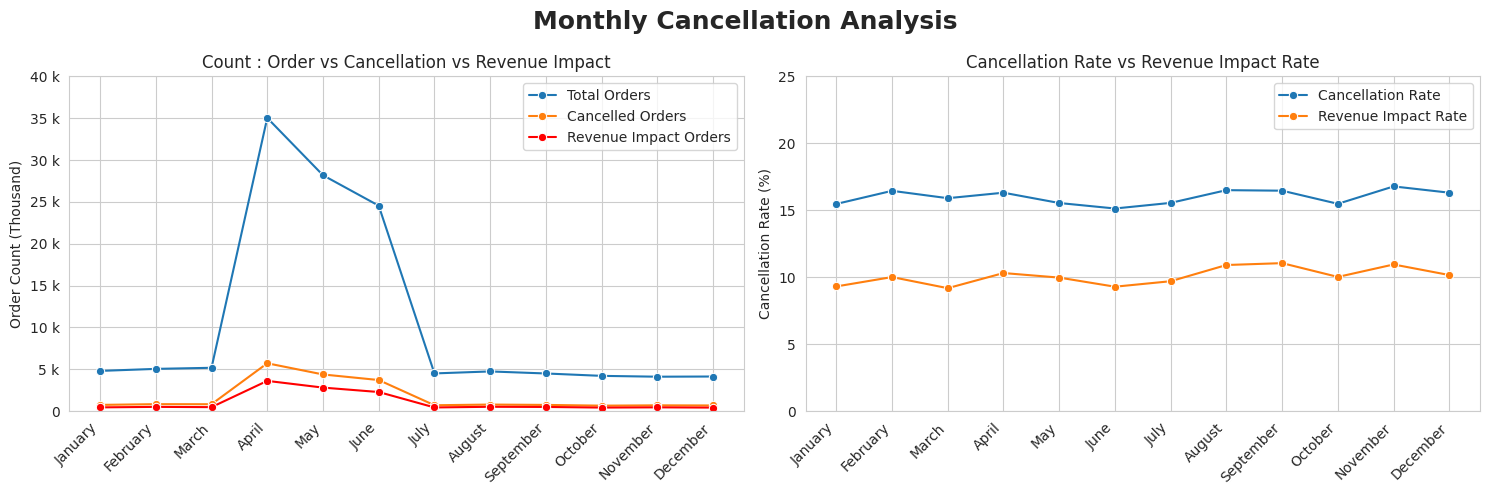

In [82]:
# CHART : PLOTTING TOTAL ORDERS VS CANCELLED ORDERS VS REVENUE IMPACT ORDERS
# ==================================================================================

fig, (ax, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
fig.suptitle('Monthly Cancellation Analysis', fontsize=18, fontweight='bold')

# Chart 1: Plotting monthly orders, cancelled orders, revenue impact order
ax = sns.lineplot(cancellation_by_month, x='months', y='total_orders', label='Total Orders', marker='o', ax=ax)
ax = sns.lineplot(cancellation_by_month, x='months', y='cancelled_orders',label='Cancelled Orders', marker='o', ax=ax)
ax = sns.lineplot(cancellation_by_month, x='months', y='revenue_impact_orders',label='Revenue Impact Orders', color='red', marker='o', ax=ax)

ax.set_title('Count : Order vs Cancellation vs Revenue Impact')
ax.set_xlabel(None)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('Order Count (Thousand)')
ax.set_ylim(0, 40000)
ax.yaxis.set_major_formatter(EngFormatter())

# Chart 2: Plotting monthly cancellation rate and impact rate
ax1 = sns.lineplot(cancellation_by_month, x='months', y='cancellation_rate', label='Cancellation Rate', marker='o', ax=ax1)
ax1 = sns.lineplot(cancellation_by_month, x='months', y='impact_rate', label='Revenue Impact Rate', marker='o', ax=ax1)

ax1.set_title('Cancellation Rate vs Revenue Impact Rate')
ax1.set_xlabel(None)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_ylabel('Cancellation Rate (%)')
ax1.set_ylim(0,25)
ax1.yaxis.set_major_formatter(EngFormatter())

plt.tight_layout()

fig.savefig(
    'Chart3_monthly_trend_analysis.png',
    dpi = 300,
    bbox_inches = 'tight'
)

plt.show()

###Categorical Analysis
**Goal :** Analyze cancellation impact by Product Category to determine whether the impact is any category specific or equal.

**Approach :**
* Calculate order count and cancellation count by each category
* Calculate cancellation rate(%) and contribution(%) to whole cancellation
* Identify Top categories which contributes the most in cancellations

In [83]:
# CANCELLATION BREAKDOWN BY CANCELLATION
# ==============================================
category_wise_cancellation = data.groupby('category').agg(orders = ('has_cancelled', 'count'),
                                                    cancelled = ('has_cancelled', 'sum')).reset_index()

category_wise_cancellation['cancellation(%)'] = ((category_wise_cancellation['cancelled'] / category_wise_cancellation['orders']) * 100).round(2)

# CALCULATING CONTIBUTION TO CANCELLATOIN AND CUMULATIVE CANCELLATON RATE
# ==========================================================================
total_cancelled_orders = category_wise_cancellation['cancelled'].sum()

category_wise_cancellation['contribution(%)'] = (category_wise_cancellation['cancelled'] /total_cancelled_orders) * 100

category_wise_cancellation = category_wise_cancellation.sort_values('contribution(%)', ascending=False)

category_wise_cancellation['cumulative(%)'] = category_wise_cancellation['contribution(%)'].cumsum()

display(category_wise_cancellation)

,category,orders,cancelled,cancellation(%),contribution(%),cumulative(%)
5,Set,50284,8182,16.27,40.027396,40.027396
8,kurta,49877,8007,16.05,39.171273,79.198669
7,Western Dress,15500,2465,15.90,12.059097,91.257766
6,Top,10622,1410,13.27,6.897901,98.155668
3,Ethnic Dress,1159,161,13.89,0.787633,98.943300
0,Blouse,926,128,13.82,0.626192,99.569493
1,Bottom,440,66,15.00,0.322880,99.892373
4,Saree,164,22,13.41,0.107627,100.000000
2,Dupatta,3,0,0.00,0.000000,100.000000


In [84]:
# REVENUE LOSS BREAKDOWN BY CATEGORY
# ===============================================
category_wise_revenue = data.groupby('category').agg(revenue_expected = ('amount', 'sum'),
                                                    revenue_lost = ('revenue_loss', 'sum')).reset_index()

category_wise_revenue['revenue_lost(%)'] = ((category_wise_revenue['revenue_lost'] / category_wise_revenue['revenue_expected']) * 100).round(2)


# CALCULATING CONTRIBUTION TO REVENUE LOST AND CUMULATIVE REVENUE LOSS RATE
# ==========================================================================
total_revenue_lost = category_wise_revenue['revenue_lost'].sum()

category_wise_revenue['contribution(%)'] = (category_wise_revenue['revenue_lost'] /total_revenue_lost) * 100

category_wise_revenue = category_wise_revenue.sort_values('contribution(%)', ascending=False)

category_wise_revenue['cumulative(%)'] = category_wise_revenue['contribution(%)'].cumsum()

display(category_wise_revenue)


,category,revenue_expected,revenue_lost,revenue_lost(%),contribution(%),cumulative(%)
5,Set,39204124.03,4171603.03,10.64,50.237015,50.237015
8,kurta,21299546.70,2218279.70,10.41,26.713892,76.950907
7,Western Dress,11216072.69,1257522.69,11.21,15.143863,92.094770
6,Top,5347792.30,512096.30,9.58,6.166979,98.261750
3,Ethnic Dress,791217.66,70162.66,8.87,0.844942,99.106692
0,Blouse,458408.18,46747.18,10.20,0.562958,99.669650
1,Bottom,150667.98,17193.98,11.41,0.207061,99.876711
4,Saree,123933.76,10237.76,8.26,0.123289,100.000000
2,Dupatta,915.00,0.00,0.00,0.000000,100.000000


###Key Findings : (Categorical Analysis)

The cancellation rate(%) is ~13-16% and revenue loss rate(%) is ~8-11% in each of the categories where Bottom has 15% cancellation rate and the highest revenue lost rate 11.41% but contribution to cancellation is ~0.32% and revenue lost is only 0.21%. Set has highest cancellation rate ~16.27 and revenue lost rate 10.64% where cancellation contribution ~40% and revenue lost is 50.24% alone.

Cancellation and Revenue lost contribution is extremely consentrated on Top 3 categories, Set, Kurta and Western Dress. Top 3 categories are impacting to ~91% cancellation and ~92.09% revenue loss aggregated and reset 6 categories are only ~7.81%.

Focusing on Top 3 Categories to improve would save revenue loss

###Visualizing
* CHART 1: Top 3 categories contributing ~91% of cancellation
* CHART 2: Top 3 categories contributing ~92% of revenue loss

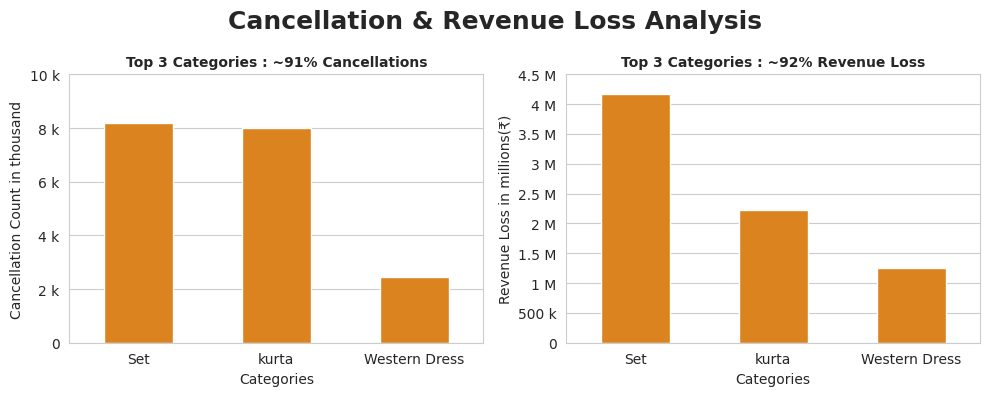

In [85]:
# PREPARING DATA FOR CHART
# ===========================================

top_category_by_cancellation = category_wise_cancellation.head(3)
top_category_by_revenue_loss = category_wise_revenue.head(3)

# PLOTTING CANCELLATION AND REVENUE LOSS
# ===========================================
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
fig.suptitle('Cancellation & Revenue Loss Analysis', fontsize=18, fontweight='bold')

# CHART 1: PLOTTING TOP 4 CATEGORIES CONTRIBUTING ~98% CANCELLATION
# ===================================================================
ax1 = sns.barplot(data=top_category_by_cancellation, x='category', y='cancelled', width=0.5, color='#fa8500', ax=ax1)

ax1.set_title('Top 3 Categories : ~91% Cancellations', fontsize=10, fontweight='bold')
ax1.set_xlabel('Categories', fontsize=10)
ax1.set_ylabel('Cancellation Count in thousand')
ax1.set_ylim(0, 10000)
ax1.yaxis.set_major_formatter(EngFormatter())


# CHART 1: PLOTTING TOP 4 CATEGORIES CONTRIBUTING ~98% REVENUE LOSS
# ===================================================================
ax2 = sns.barplot(data=top_category_by_revenue_loss,  x='category', y='revenue_lost', width=0.5, color='#fa8500', ax=ax2)

ax2.set_title('Top 3 Categories : ~92% Revenue Loss', fontsize=10, fontweight='bold')
ax2.set_xlabel('Categories', fontsize=10)
ax2.set_ylabel('Revenue Loss in millions(₹)')
ax2.set_ylim(0, 4500000)
ax2.yaxis.set_major_formatter(EngFormatter())

plt.tight_layout()

fig.savefig(
    'Chart4_top_3_categories_cancellation_revenue.png',
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

###Summerizing Insights

**Overall Business Impact :** Analysis of 128,975 orders across full year 2022.

* ~16% cancellation rate (20,441 orders cancelled out of 128,975). However, only ~10% of total orders have revenue impact (revenue loss from cancelled orders).
* ~11% revenue loss rate (₹ 8296548.3 out of  ₹ 78592678.3)

**Volume > Rate:** High-volume states/categories contribute far more to absolute cancellations and revenue loss than low-volume ones with elevated rates. Absolute numbers matter most than rate for business impact.

**Concentration:** Cancellations and revenue loss are not uniform, they are concentrated in high volume states and categories.

* Top 5 states (Maharashtra, Karnataka, Uttar Pradesh, Telangana, Tamil Nadu) drive ~54% of cancellations and ~53% of revenue loss.

* Top 3 categories (Sets, Kurtas, Western Dress) drive ~91% of cancellations and ~92% of revenue loss.

* Actionable: Targeting Top 5 states and 3 Categories to improve would resolves >50% of the business problem.

**Trends:** Monthly cancellation rate ~15-16% and revenue impact rate ~9-11% are stable through out the year, issue is structural/process-related, not seasonal. Absolute volumes spiked ~7x in Apr-Jun with same cancellation rates, confirming volume drives exposure.